# EJERCICIO : COMPARAR MODELOS DE REGRESION PARA ESTE DATASET
## DATASET [kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)

In [1]:
DATASET_URL = 'https://github.com/stedy/Machine-Learning-with-R-datasets/raw/refs/heads/master/insurance.csv'

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [4]:
df = pd.read_csv(DATASET_URL)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


 # PASO 3 : EDA

In [5]:
df.isna().sum().sum()

np.int64(0)

In [6]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [9]:
df_cleaned = remove_outliers(df,'bmi')
df_cleaned = remove_outliers(df_cleaned,'age')
df_cleaned = remove_outliers(df_cleaned,'charges')
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

In [10]:
categorical_columns = df_cleaned.select_dtypes(object).columns
categorical_columns

Index(['sex', 'smoker', 'region'], dtype='object')

In [11]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
sex
male      676
female    662
Name: count, dtype: int64
**************************************************
smoker
no     1064
yes     274
Name: count, dtype: int64
**************************************************
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [12]:
ordinal_cols = ['sex','smoker']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['sex', 'smoker'] ['region']


In [13]:
import sklearn.compose
import sklearn.preprocessing

In [14]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['sex', 'smoker']),
                                ('onehotencoder', OneHotEncoder(), ['region'])])

In [15]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df_cleaned),
        columns = transformer.get_feature_names_out(),
        index=df_cleaned.index
    )
)
data_transformed_df

,ordinalencoder__sex,ordinalencoder__smoker,onehotencoder__region_northeast,onehotencoder__region_northwest,onehotencoder__region_southeast,onehotencoder__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__charges
0,0.0,1.0,0.0,0.0,0.0,1.0,19.0,27.900,0.0,16884.92400
1,1.0,0.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,1725.55230
2,1.0,0.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,4449.46200
3,1.0,0.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,21984.47061
4,1.0,0.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,3866.85520
...,...,...,...,...,...,...,...,...,...,...
1333,1.0,0.0,0.0,1.0,0.0,0.0,50.0,30.970,3.0,10600.54830
1334,0.0,0.0,1.0,0.0,0.0,0.0,18.0,31.920,0.0,2205.98080
1335,0.0,0.0,0.0,0.0,1.0,0.0,18.0,36.850,0.0,1629.83350
1336,0.0,0.0,0.0,0.0,0.0,1.0,21.0,25.800,0.0,2007.94500


In [16]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,sex,smoker,region_northeast,region_northwest,region_southeast,region_southwest,age,bmi,children,charges
0,0.0,1.0,0.0,0.0,0.0,1.0,19.0,27.900,0.0,16884.92400
1,1.0,0.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,1725.55230
2,1.0,0.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,4449.46200
3,1.0,0.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,21984.47061
4,1.0,0.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,3866.85520
...,...,...,...,...,...,...,...,...,...,...
1333,1.0,0.0,0.0,1.0,0.0,0.0,50.0,30.970,3.0,10600.54830
1334,0.0,0.0,1.0,0.0,0.0,0.0,18.0,31.920,0.0,2205.98080
1335,0.0,0.0,0.0,0.0,1.0,0.0,18.0,36.850,0.0,1629.83350
1336,0.0,0.0,0.0,0.0,0.0,1.0,21.0,25.800,0.0,2007.94500


In [17]:
data_transformed_df.dtypes

,0
sex,float64
smoker,float64
region_northeast,float64
region_northwest,float64
region_southeast,float64
region_southwest,float64
age,float64
bmi,float64
children,float64
charges,float64


In [18]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['charges']
corr_charges.sort_values(ascending=False)

,charges
charges,1.000000
smoker,0.596213
age,0.448798
children,0.089083
region_northeast,0.067055
region_northwest,0.037770
sex,-0.022893
region_southeast,-0.029093
bmi,-0.064483
region_southwest,-0.076394


<Axes: >

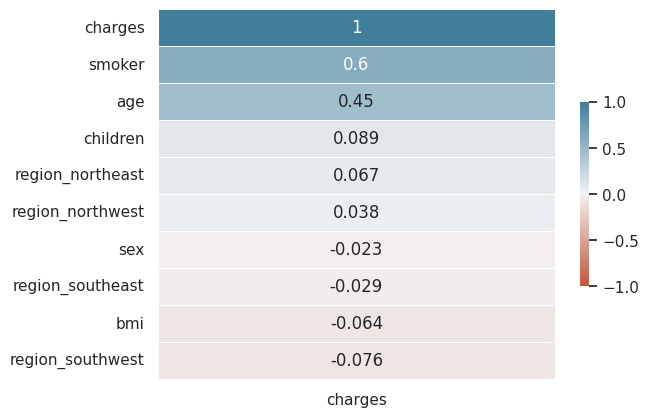

In [19]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [20]:
cols = corr_charges.index.tolist()
cols.remove('charges')
cols

['sex',
 'smoker',
 'region_northeast',
 'region_northwest',
 'region_southeast',
 'region_southwest',
 'age',
 'bmi',
 'children']

In [22]:
X = data_transformed_df[cols].values
y = data_transformed_df['charges'].values.reshape(-1,1)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.fit_transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.fit_transform(y_test)